In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Read file
df_path = "Spring2025AI_Week02_IntroToPython_epidemiology.csv"
covid_df = pd.read_csv(df_path)
print("File loaded!", covid_df.shape)

File loaded! (12525825, 10)


In [3]:
# filtering data from Brazil 
brazil_covid_df = covid_df [covid_df['location_key'] == "BR"]
print ("Brazil:", brazil_covid_df.shape)

Brazil: (989, 10)


In [4]:
# Calculate mortality rate from Brazil
brazil_covid_df = brazil_covid_df [(brazil_covid_df['new_confirmed']>0) & (brazil_covid_df['new_deceased']>0)]
brazil_covid_df['mortality_rate'] = brazil_covid_df['new_deceased'] / brazil_covid_df['new_confirmed']
print(brazil_covid_df['mortality_rate'].mean())

0.023684859608039833


In [5]:
# Add year column and group by year
brazil_covid_df['date'] = pd.to_datetime(brazil_covid_df['date'])
brazil_covid_df['year'] = brazil_covid_df['date'].dt.year
mortality_by_year_br = brazil_covid_df.groupby(['year'])['mortality_rate'].mean()
print(mortality_by_year_br)

year
2020    0.033057
2021    0.028336
2022    0.006588
Name: mortality_rate, dtype: float64


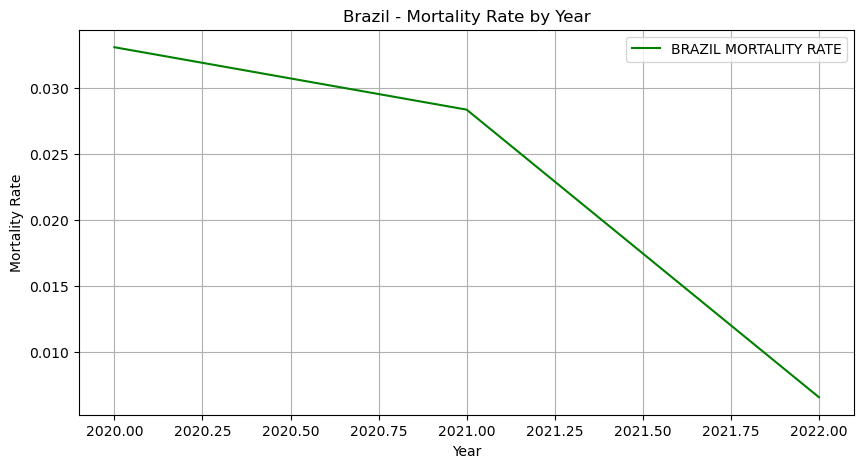

In [6]:
# Plot mortality rate for Brazil
mortality_rate_br_df = mortality_by_year_br.reset_index()
mortality_rate_br_df.columns = ['year', 'average_mortality_rate']

plt.figure(figsize=(10,5))
plt.plot(mortality_rate_br_df['year'], mortality_rate_br_df['average_mortality_rate'], color="green", label="BRAZIL MORTALITY RATE")
plt.xlabel("Year")
plt.ylabel("Mortality Rate")
plt.title("Brazil - Mortality Rate by Year")
plt.legend()
plt.grid(True)
plt.show()